# Causal Discovery Under a Simulator: Lessons from the ADIA Lab Challenge

**Chapter 15: Causal Machine Learning**
**Docker image**: `ml4t`

This notebook explores the **ADIA Lab Causal Discovery Challenge** (Olivetti et al., 2026)
as a **cautionary, clarifying example** of what synthetic benchmarks can and cannot
demonstrate about causal discovery.

**The Key Insight**: ADIA is best interpreted as a benchmark for **amortized inference
under a known simulator family**, not as evidence that "AI can discover causal structure"
in the usual scientific sense. Supervised models won because they learned the simulator's
mapping from dependence patterns to labels, not because they discovered causality.

**What ADIA Shows**:
- If you have many labeled dataset–DAG pairs from the same data-generating process,
  supervised methods can outperform classical discovery on new samples from that family

**What ADIA Does NOT Show**:
- That observational data alone is sufficient for reliable causal discovery
- That these models transfer to real financial data with unmeasured confounding,
  nonstationarity, and endogenous sampling

**Learning Outcomes**:
- LO1: Understand the "special setting" where supervised causal discovery applies
- LO2: Recognize why synthetic benchmarks can be misleading ("varsortability" critique)
- LO3: Apply discovery outputs as hypothesis generators, not final answers
- LO4: Integrate causal proposals into a finance-appropriate validation pipeline

**Book Reference**: Chapter 15, Section 15.6 (Causal Discovery from Observational Data)

**Prerequisites**: `07_tigramite_time_series` and `08_neural_causal_discovery`

## 1. Setup and Configuration

In [1]:
"""Causal discovery under a simulator: lessons from the ADIA Lab Challenge."""

import warnings

# lightgbm must be imported before scikit-learn. Both ship their own OpenMP
# runtime and the first one loaded wins for the whole process; on macOS ARM64,
# getting scikit-learn's libomp first makes LightGBM's next multithreaded fit
# segfault in __kmp_suspend_initialize_thread, killing the kernel with no
# traceback. The `import lightgbm` further down, beside the training cell that
# uses it, cannot fix this - by then the module header has already lost the
# race - so the binding is established here and re-stated there for the reader.
import lightgbm as lgb  # noqa: F401
import numpy as np
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from scipy import stats
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold

from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
N_DATASETS = 2000
N_SAMPLES = 1000
N_SPLITS = 5
SEED = 42
N_ESTIMATORS = 500

In [3]:
set_global_seeds(SEED)

## 2. What ADIA Actually Measures (and What It Doesn't)

### The Special Setting

The ADIA competition operates in a **"special setting"** that differs fundamentally
from real-world causal discovery:

1. **Many labeled dataset–DAG pairs** from the same data-generating process
2. **Scoring reduces predicted DAGs to role classification** (8 categories around X and Y)
3. **Synthetic data** with no unmeasured confounding, measurement error, or nonstationarity

This design turns "causal discovery" into **high-dimensional pattern recognition**:
learn a mapping from sample-level dependence patterns to role labels, where the
mapping is stable because the simulator is stable.

### Why Supervised Learning Wins Here

Supervised models dominate because:

1. **Training labels remove the identifiability bottleneck**: The learner doesn't
   need to solve identifiability; it learns any stable statistical signature
2. **The task is narrower**: Role classification in a 1-hop neighborhood is easier
   than reconstructing an entire DAG up to Markov equivalence
3. **Hybrid entries used classical outputs as features**: PC/NOTEARS outputs become
   inputs to boosted trees as classical discovery feature engineering

### The "Varsortability" Critique

Reisach et al. (2021) warn that synthetic DAG benchmarks can be "gamed" because
common simulation schemes create artifacts correlated with causal order. A model
can win by learning **simulator quirks rather than transferable causal principles**.

### What This Does NOT Show

ADIA does **not** support the claim that observational data in the wild is sufficient
for reliable causal discovery. The hard parts are deliberately excluded:

- Unmeasured confounding (absent in synthetic data)
- Measurement error, nonstationarity, regime changes
- Feedback loops and simultaneity
- Selection effects and endogenous sampling
- Time-order constraints and mixed frequencies

---

## 3. The 8 Causal Categories

The ADIA challenge defines **8 causal categories** for each variable in a DAG
relative to a designated treatment (X) and outcome (Y):

| Category | Description | DAG Position |
|----------|-------------|--------------|
| **Confounder** | Common cause of X and Y | X ← Z → Y |
| **Collider** | Common effect of X and Y | X → Z ← Y |
| **Mediator** | On causal path | X → Z → Y |
| **Independent** | No relationship | Z ⊥ (X,Y) |
| **Cause of X** | Direct parent of X | Z → X |
| **Consequence of X** | Direct child of X (not Y) | X → Z (Z ≠ Y) |
| **Cause of Y** | Direct parent of Y (not X) | Z → Y (Z ≠ X) |
| **Consequence of Y** | Direct child of Y | Y → Z |

**Why This Is Hard**: Given only observational data, distinguishing these categories
requires inferring the underlying causal structure, which is exactly what traditional
algorithms like PC and NOTEARS struggle with.

In [4]:
# Define the 8 causal categories
CAUSAL_CATEGORIES = {
    0: "Confounder",  # Common cause of X and Y
    1: "Collider",  # Common effect of X and Y
    2: "Mediator",  # On causal path X → M → Y
    3: "Independent",  # No causal relationship
    4: "Cause of X",  # Direct cause of treatment
    5: "Consequence of X",  # Direct effect of treatment (not Y)
    6: "Cause of Y",  # Direct cause of outcome (not X)
    7: "Consequence of Y",  # Direct effect of outcome
}

## 4. Generate Synthetic Training Data with Known DAGs

The ADIA challenge provided 25,000 training datasets with ground-truth DAGs.
We generate our own synthetic data to demonstrate the methodology.

**Data Generation Protocol**:
1. Generate random DAGs with 5-8 variables and randomized topological order
2. Designate treatment (X) and outcome (Y), enforcing the challenge's X → Y edge
3. Classify each other variable into one of 8 categories
4. Generate observational data from the DAG
5. Create labeled training examples

### Generate Random DAGs

A random topological permutation guarantees acyclicity without letting a variable's
numeric column position reveal whether it is upstream or downstream.

In [5]:
def generate_random_dag(n_vars: int, edge_prob: float = 0.3) -> tuple[np.ndarray, np.ndarray]:
    """Generate a random DAG and return its hidden topological order."""
    order = np.random.permutation(n_vars)
    W = np.zeros((n_vars, n_vars))
    for source_pos in range(n_vars):
        for target_pos in range(source_pos + 1, n_vars):
            if np.random.random() < edge_prob:
                W[order[source_pos], order[target_pos]] = 1
    return W, order

### Classify Variable Roles

Given a DAG, classify each variable Z relative to treatment X and outcome Y
into one of the 8 causal categories defined above.

In [6]:
def classify_variable(W: np.ndarray, x_idx: int, y_idx: int, z_idx: int) -> int:
    """Classify variable Z relative to treatment X and outcome Y. Returns category 0-7."""
    z_causes_x = W[z_idx, x_idx] == 1
    x_causes_z = W[x_idx, z_idx] == 1
    z_causes_y = W[z_idx, y_idx] == 1
    y_causes_z = W[y_idx, z_idx] == 1

    is_mediator = x_causes_z and z_causes_y
    is_confounder = z_causes_x and z_causes_y
    is_collider = x_causes_z and y_causes_z

    if is_confounder:
        return 0
    elif is_collider:
        return 1
    elif is_mediator:
        return 2
    elif z_causes_x and not z_causes_y:
        return 4  # Cause of X only
    elif x_causes_z and not z_causes_y and not y_causes_z:
        return 5  # Consequence of X
    elif z_causes_y and not z_causes_x:
        return 6  # Cause of Y only
    elif y_causes_z:
        return 7  # Consequence of Y
    else:
        return 3  # Independent

### Generate Data from DAG

Generate observational data from a linear Gaussian DAG in its hidden topological order.

In [7]:
def generate_data_from_dag(
    W: np.ndarray,
    order: np.ndarray,
    n_samples: int = 1000,
    noise_scale: float = 1.0,
) -> np.ndarray:
    """Generate observational data from a linear Gaussian DAG."""
    n_vars = W.shape[0]
    W_weighted = W * np.random.uniform(0.5, 1.5, size=W.shape)

    X = np.zeros((n_samples, n_vars))
    for j in order:
        parents = np.where(W_weighted[:, j] > 0)[0]
        noise = np.random.randn(n_samples) * noise_scale
        if len(parents) == 0:
            X[:, j] = noise
        else:
            X[:, j] = X[:, parents] @ W_weighted[parents, j] + noise

    return X

### Synthetic Training Dataset Generator

Build randomized DAG datasets with labeled variable roles for supervised
classification of causal structure categories.

In [8]:
def generate_training_dataset(
    n_datasets: int = 1000,
    min_vars: int = 5,
    max_vars: int = 8,
    n_samples: int = 1000,
) -> tuple[list, list, list]:
    """
    Generate synthetic training data with known causal categories.

    Returns:
        datasets: List of data matrices
        labels: List of label arrays (one per variable, excluding X and Y)
        metadata: List of (W, x_idx, y_idx) tuples
    """
    datasets = []
    labels = []
    metadata = []

    for _ in range(n_datasets):
        n_vars = np.random.randint(min_vars, max_vars + 1)
        W, order = generate_random_dag(n_vars, edge_prob=0.35)
        x_pos, y_pos = sorted(np.random.choice(n_vars, size=2, replace=False))
        x_idx, y_idx = order[x_pos], order[y_pos]
        W[x_idx, y_idx] = 1
        X = generate_data_from_dag(W, order, n_samples)

        dataset_labels = []
        for z_idx in range(n_vars):
            if z_idx in (x_idx, y_idx):
                continue
            category = classify_variable(W, x_idx, y_idx, z_idx)
            dataset_labels.append((z_idx, category))

        datasets.append(X)
        labels.append(dataset_labels)
        metadata.append((W, x_idx, y_idx))

    return datasets, labels, metadata

In [9]:
datasets, labels, metadata = generate_training_dataset(
    n_datasets=N_DATASETS,
    min_vars=5,
    max_vars=8,
    n_samples=N_SAMPLES,
)

all_labels = [category for label_list in labels for _, category in label_list]
label_counts = np.bincount(all_labels, minlength=len(CAUSAL_CATEGORIES))

print(f"Generated {len(datasets):,} DAG datasets with {len(all_labels):,} labeled nodes")
print(f"Challenge invariant X -> Y satisfied: {all(W[x, y] == 1 for W, x, y in metadata)}")

Generated 2,000 DAG datasets with 8,972 labeled nodes
Challenge invariant X -> Y satisfied: True


## 5. Feature Engineering: Statistical Signatures of Causal Roles

Strong competition entries combined engineered statistical features and learned
representations. This compact surrogate uses four feature families:

1. **Correlation Statistics**: Pearson, Spearman, partial correlations
2. **Conditional Independence**: CI test p-values, conditional correlations
3. **Regression Diagnostics**: directional coefficients and fit statistics
4. **Distribution Shape**: variance, skewness, and kurtosis

Numeric column positions are deliberately excluded. Because the simulator uses a randomized
topological order, an identifier cannot reveal whether a variable is upstream or downstream.

In [10]:
def compute_partial_correlation(data: np.ndarray, i: int, j: int, conditioning_set: list) -> float:
    """Compute partial correlation between variables i and j given conditioning set."""
    if len(conditioning_set) == 0:
        return np.corrcoef(data[:, i], data[:, j])[0, 1]

    from sklearn.linear_model import LinearRegression

    X_cond = data[:, conditioning_set]
    resid_i = data[:, i] - LinearRegression().fit(X_cond, data[:, i]).predict(X_cond)
    resid_j = data[:, j] - LinearRegression().fit(X_cond, data[:, j]).predict(X_cond)
    return np.corrcoef(resid_i, resid_j)[0, 1]

### Conditional Independence Test Feature

Fisher-z transformed partial-correlation test used as a core engineered
feature for the ADIA benchmark classifier.

In [11]:
def ci_test_pvalue(data: np.ndarray, i: int, j: int, conditioning_set: list) -> float:
    """Return the Fisher-z p-value for conditional independence."""
    n, k = len(data), len(conditioning_set)
    partial_corr = compute_partial_correlation(data, i, j, conditioning_set)

    if np.isnan(partial_corr) or abs(partial_corr) >= 1:
        return 1.0

    z = 0.5 * np.log((1 + partial_corr) / (1 - partial_corr))
    z_stat = abs(z) / (1.0 / np.sqrt(n - k - 3))
    return 2 * stats.norm.sf(z_stat)

### Core Feature Extraction

Extract correlation, partial correlation, CI p-values, and regression features.

In [12]:
def _extract_correlation_features(data, x_idx, y_idx, z_idx):
    """Correlations, partial correlations, and CI test p-values."""
    f = {}
    f["corr_z_x"] = np.corrcoef(data[:, z_idx], data[:, x_idx])[0, 1]
    f["corr_z_y"] = np.corrcoef(data[:, z_idx], data[:, y_idx])[0, 1]
    f["corr_x_y"] = np.corrcoef(data[:, x_idx], data[:, y_idx])[0, 1]
    f["abs_corr_z_x"] = abs(f["corr_z_x"])
    f["abs_corr_z_y"] = abs(f["corr_z_y"])

    f["partial_z_x_given_y"] = compute_partial_correlation(data, z_idx, x_idx, [y_idx])
    f["partial_z_y_given_x"] = compute_partial_correlation(data, z_idx, y_idx, [x_idx])
    f["partial_x_y_given_z"] = compute_partial_correlation(data, x_idx, y_idx, [z_idx])

    f["ci_pvalue_z_x"] = ci_test_pvalue(data, z_idx, x_idx, [])
    f["ci_pvalue_z_y"] = ci_test_pvalue(data, z_idx, y_idx, [])
    f["ci_pvalue_z_x_given_y"] = ci_test_pvalue(data, z_idx, x_idx, [y_idx])
    f["ci_pvalue_z_y_given_x"] = ci_test_pvalue(data, z_idx, y_idx, [x_idx])
    f["ci_pvalue_x_y_given_z"] = ci_test_pvalue(data, x_idx, y_idx, [z_idx])
    return f

### Regression and Statistical Features

Regression coefficients for directionality plus higher-order distribution statistics.

In [13]:
def extract_features(data: np.ndarray, x_idx: int, y_idx: int, z_idx: int) -> dict:
    """Extract all features for classifying variable Z relative to X and Y."""
    from sklearn.linear_model import LinearRegression

    features = _extract_correlation_features(data, x_idx, y_idx, z_idx)

    # Regression coefficients (direction indicators)
    for src, tgt, prefix in [
        (z_idx, x_idx, "z_to_x"),
        (x_idx, z_idx, "x_to_z"),
        (z_idx, y_idx, "z_to_y"),
        (y_idx, z_idx, "y_to_z"),
    ]:
        m = LinearRegression().fit(data[:, [src]], data[:, tgt])
        features[f"reg_coef_{prefix}"] = m.coef_[0]
        features[f"reg_r2_{prefix}"] = m.score(data[:, [src]], data[:, tgt])

    # Higher-order statistics
    features["skew_z"] = stats.skew(data[:, z_idx])
    features["kurtosis_z"] = stats.kurtosis(data[:, z_idx])
    features["skew_x"] = stats.skew(data[:, x_idx])
    features["skew_y"] = stats.skew(data[:, y_idx])

    # Variance ratios
    features["var_z"] = np.var(data[:, z_idx])
    features["var_ratio_z_x"] = np.var(data[:, z_idx]) / (np.var(data[:, x_idx]) + 1e-10)
    features["var_ratio_z_y"] = np.var(data[:, z_idx]) / (np.var(data[:, y_idx]) + 1e-10)

    # Spearman (rank-based)
    features["spearman_z_x"] = stats.spearmanr(data[:, z_idx], data[:, x_idx])[0]
    features["spearman_z_y"] = stats.spearmanr(data[:, z_idx], data[:, y_idx])[0]

    for key, value in features.items():
        if not np.isfinite(value):
            features[key] = 0.0
    return features

In [14]:
all_features = []
all_targets = []
all_dataset_ids = []

for dataset_id, (data, label_list, (W, x_idx, y_idx)) in enumerate(
    zip(datasets, labels, metadata, strict=True)
):
    for z_idx, category in label_list:
        features = extract_features(data, x_idx, y_idx, z_idx)
        all_features.append(features)
        all_targets.append(category)
        all_dataset_ids.append(dataset_id)

    if (dataset_id + 1) % 500 == 0:
        print(f"  Processed {dataset_id + 1}/{len(datasets)} datasets")

feature_df = pl.DataFrame(all_features)
X_train = feature_df.to_numpy()
y_train = np.array(all_targets)
groups = np.array(all_dataset_ids)

print(f"\nFeature matrix shape: {X_train.shape}")
print(f"Number of features: {feature_df.shape[1]}")

  Processed 500/2000 datasets


  Processed 1000/2000 datasets


  Processed 1500/2000 datasets


  Processed 2000/2000 datasets

Feature matrix shape: (8972, 30)
Number of features: 30


## 6. Baseline: Conditional-Independence Heuristic

Traditional constraint-based baselines achieved approximately 40% balanced accuracy in the
official challenge. The compact rule below is not the PC algorithm: it maps marginal and
conditional-independence tests directly to the eight roles. It provides an in-notebook baseline
on exactly the same simulated datasets as the supervised model.

In [15]:
def ci_heuristic_baseline(features: dict[str, float]) -> int:
    """Map conditional-independence tests to one of the eight causal roles."""
    alpha = 0.05
    p_zx = features["ci_pvalue_z_x"]
    p_zy = features["ci_pvalue_z_y"]
    p_zx_given_y = features["ci_pvalue_z_x_given_y"]
    p_zy_given_x = features["ci_pvalue_z_y_given_x"]
    p_xy_given_z = features["ci_pvalue_x_y_given_z"]

    if p_zx > alpha and p_zy > alpha:
        return 3  # Independent
    if p_zx < alpha and p_zy < alpha:
        if p_xy_given_z > p_zx * p_zy:
            return 0  # Confounder
        if p_zx_given_y > alpha and p_zy_given_x > alpha:
            return 2  # Mediator
    if p_zx < alpha and p_zy_given_x > alpha:
        return 4  # Cause of X
    if p_zy < alpha and p_zx_given_y > alpha:
        return 6  # Cause of Y
    if p_zx < alpha:
        return 5  # Consequence of X
    if p_zy < alpha:
        return 7  # Consequence of Y
    return 3  # Default: Independent

In [16]:
baseline_predictions = [ci_heuristic_baseline(features) for features in all_features]
baseline_true_labels = all_targets

baseline_accuracy = balanced_accuracy_score(baseline_true_labels, baseline_predictions)
print(f"CI heuristic balanced accuracy: {baseline_accuracy:.1%}")

CI heuristic balanced accuracy: 17.7%


## 7. Supervised Learning: Group-Isolated LightGBM

The winning solutions used supervised classifiers trained on the 25,000 datasets
with known ground truth. Here, grouped cross-validation keeps every node from a simulated DAG
in one fold. LightGBM operates on the unscaled features, so no preprocessing state can cross a
fold boundary. Deterministic CPU training fixes the histogram layout, thread count, and all
relevant seeds so repeated runs in the pinned environment reproduce the fitted models exactly.

In [17]:
import lightgbm as lgb

In [18]:
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
n_estimators = N_ESTIMATORS

In [19]:
all_oof_preds = np.zeros(len(y_train), dtype=int)
fold_scores = []
fold_importances = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    assert not set(groups[train_idx]).intersection(groups[val_idx])

    model = lgb.LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        random_state=SEED,
        seed=SEED,
        data_random_seed=SEED,
        feature_fraction_seed=SEED,
        bagging_seed=SEED,
        drop_seed=SEED,
        extra_seed=SEED,
        objective_seed=SEED,
        device_type="cpu",
        deterministic=True,
        force_col_wise=True,
        n_jobs=1,
        verbose=-1,
        class_weight="balanced",
    )

    model.fit(X_tr, y_tr)
    fold_predictions = model.predict(X_val)
    all_oof_preds[val_idx] = fold_predictions
    fold_acc = balanced_accuracy_score(y_val, fold_predictions)
    fold_scores.append(fold_acc)
    gain = model.booster_.feature_importance(importance_type="gain")
    fold_importances.append(gain / gain.sum())
    print(f"  Fold {fold + 1}: Balanced Accuracy = {fold_acc:.1%}")

  Fold 1: Balanced Accuracy = 76.2%


  Fold 2: Balanced Accuracy = 75.5%


  Fold 3: Balanced Accuracy = 75.4%


  Fold 4: Balanced Accuracy = 74.5%


  Fold 5: Balanced Accuracy = 76.7%


In [20]:
oof_accuracy = balanced_accuracy_score(y_train, all_oof_preds)
print(f"\nOverall OOF Balanced Accuracy: {oof_accuracy:.1%}")
print(f"Mean ± std across folds: {np.mean(fold_scores):.1%} ± {np.std(fold_scores):.1%}")
print("ADIA winner (reported external benchmark): 76.70%")


Overall OOF Balanced Accuracy: 75.7%
Mean ± std across folds: 75.7% ± 0.8%
ADIA winner (reported external benchmark): 76.70%


## 8. Model Diagnostics

Role-specific accuracy shows where supervised pattern recognition helps and where observational
equivalence remains difficult. The comparison uses identical generated datasets for both methods.

In [21]:
per_category_rows = []
baseline_true_arr = np.array(baseline_true_labels)
baseline_pred_arr = np.array(baseline_predictions)
for cat_idx, cat_name in CAUSAL_CATEGORIES.items():
    mask_baseline = baseline_true_arr == cat_idx
    baseline_acc = (baseline_pred_arr[mask_baseline] == cat_idx).mean()
    mask_sup = y_train == cat_idx
    sup_acc = (all_oof_preds[mask_sup] == cat_idx).mean()
    per_category_rows.append(
        {
            "Category": cat_name,
            "CI heuristic": baseline_acc,
            "Supervised": sup_acc,
            "Improvement": sup_acc - baseline_acc,
        }
    )

per_category_df = pl.DataFrame(per_category_rows)

### Fold-Stable Feature Importance

Gain importance can vary across fitted trees, so the chart reports the mean and standard deviation
across the five training folds rather than a single full-sample model.

In [22]:
importance_array = np.vstack(fold_importances)
importance_df = pl.DataFrame(
    {
        "Feature": feature_df.columns,
        "Mean gain share": importance_array.mean(axis=0),
        "Std gain share": importance_array.std(axis=0),
    }
).sort("Mean gain share", descending=True)

## 9. Visual Evidence

### The Simulator Is Imbalanced

Balanced accuracy is the appropriate score because independent nodes are much more frequent than
several directional roles. Raw accuracy would let the largest category dominate.

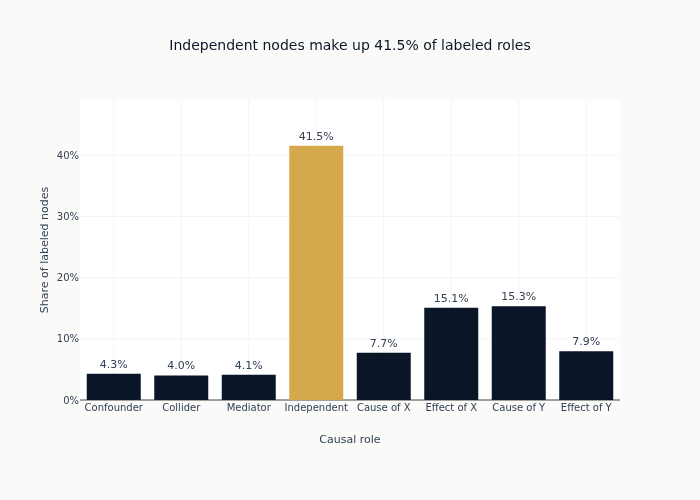

In [23]:
category_tick_labels = [
    "Confounder",
    "Collider",
    "Mediator",
    "Independent",
    "Cause of X",
    "Effect of X",
    "Cause of Y",
    "Effect of Y",
]
category_compact_labels = [
    "Conf.",
    "Coll.",
    "Med.",
    "Indep.",
    "Cause X",
    "Effect X",
    "Cause Y",
    "Effect Y",
]
category_shares = label_counts / label_counts.sum()
largest_category = int(np.argmax(category_shares))

fig = go.Figure(
    go.Bar(
        x=category_tick_labels,
        y=category_shares,
        marker_color=[
            COLORS["amber"] if i == largest_category else COLORS["blue"]
            for i in range(len(category_tick_labels))
        ],
        text=[f"{share:.1%}" for share in category_shares],
        textposition="outside",
    )
)
fig.update_layout(
    title=(
        f"{category_tick_labels[largest_category]} nodes make up "
        f"{category_shares[largest_category]:.1%} of labeled roles"
    ),
    xaxis_title="Causal role",
    yaxis_title="Share of labeled nodes",
    yaxis=dict(range=[0, max(category_shares) * 1.18], tickformat=".0%"),
    margin=dict(b=100),
    showlegend=False,
)
fig.show()

### Supervision Helps Across Roles

Comparing each role on the same datasets reveals whether the aggregate gain is broad or driven by
one dominant class.

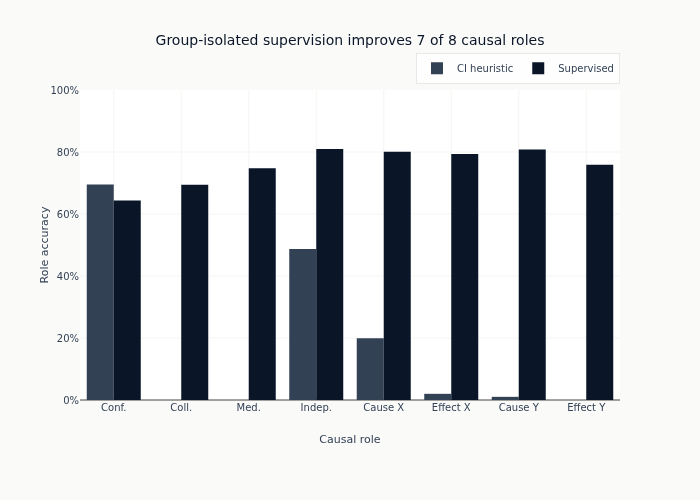

In [24]:
improved_count = int((per_category_df["Improvement"] > 0).sum())
fig = go.Figure()
for method, color in [("CI heuristic", COLORS["neutral"]), ("Supervised", COLORS["blue"])]:
    fig.add_trace(
        go.Bar(
            x=category_compact_labels,
            y=per_category_df[method].to_list(),
            name=method,
            marker_color=color,
        )
    )
fig.update_layout(
    title=f"Group-isolated supervision improves {improved_count} of 8 causal roles",
    xaxis_title="Causal role",
    yaxis_title="Role accuracy",
    yaxis=dict(range=[0, 1], tickformat=".0%"),
    barmode="group",
    margin=dict(b=100, t=90),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

### Confusion Matrix

Row-normalized rates expose which roles remain observationally difficult after supervised
training; hover text retains the underlying counts.

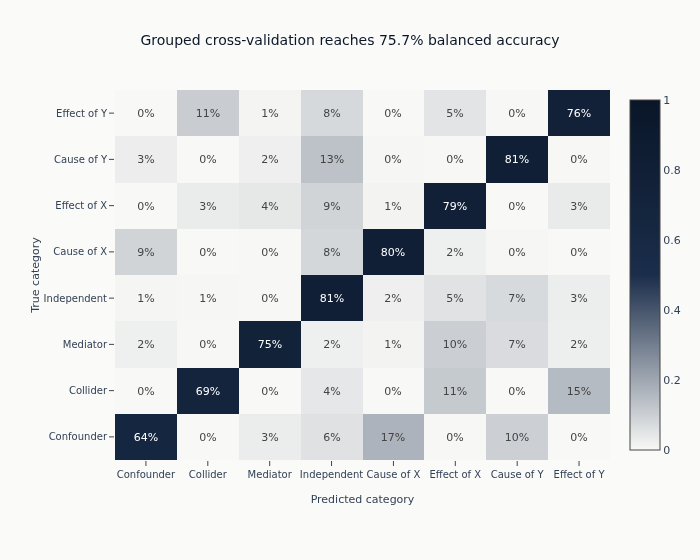

In [25]:
conf_matrix = confusion_matrix(y_train, all_oof_preds)
conf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1, keepdims=True)

fig = go.Figure(
    data=go.Heatmap(
        z=conf_matrix_normalized,
        x=category_tick_labels,
        y=category_tick_labels,
        colorscale=[
            [0.0, COLORS["silver"]],
            [0.5, COLORS["slate"]],
            [1.0, COLORS["blue"]],
        ],
        zmin=0,
        zmax=1,
        customdata=conf_matrix,
        texttemplate="%{z:.0%}",
        hovertemplate=(
            "True: %{y}<br>Predicted: %{x}<br>Count: %{customdata}<br>Rate: %{z:.1%}<extra></extra>"
        ),
    )
)
fig.update_layout(
    title=f"Grouped cross-validation reaches {oof_accuracy:.1%} balanced accuracy",
    xaxis_title="Predicted category",
    yaxis_title="True category",
    height=560,
    margin=dict(l=115, b=100, t=90, r=60),
)
fig.show()

### Feature Importance

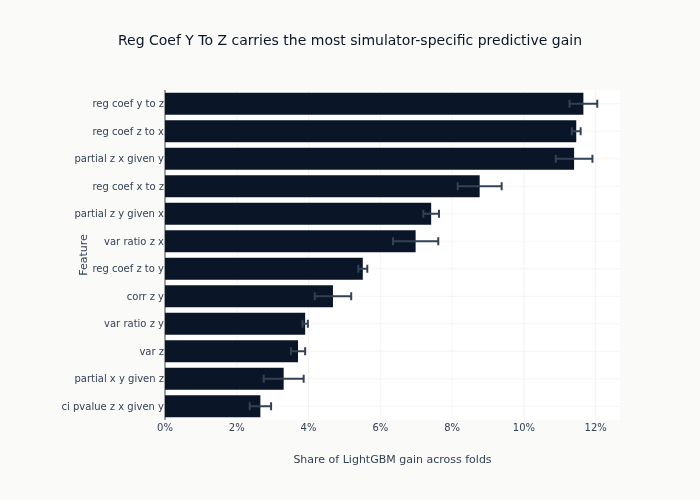

In [26]:
top_features = importance_df.head(12).sort("Mean gain share")
top_feature_name = importance_df["Feature"][0].replace("_", " ")
top_feature_labels = [name.replace("_", " ") for name in top_features["Feature"]]
fig = go.Figure(
    data=go.Bar(
        x=top_features["Mean gain share"].to_list(),
        y=top_feature_labels,
        orientation="h",
        marker_color=COLORS["blue"],
        error_x=dict(
            type="data",
            array=top_features["Std gain share"].to_list(),
            color=COLORS["neutral"],
        ),
    )
)
fig.update_layout(
    title=f"{top_feature_name.title()} carries the most simulator-specific predictive gain",
    xaxis_title="Share of LightGBM gain across folds",
    yaxis_title="Feature",
    height=500,
    xaxis=dict(tickformat=".0%"),
    margin=dict(l=165, t=90),
)
fig.show()

### Method Comparison

The first two bars share this notebook's simplified simulator. The final bar is the reported ADIA
winner and provides external context, not a like-for-like ranking.

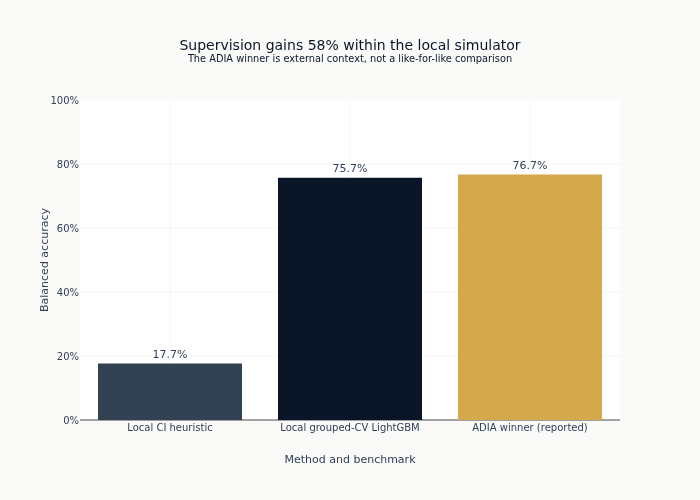

In [27]:
method_names = [
    "Local CI heuristic",
    "Local grouped-CV LightGBM",
    "ADIA winner (reported)",
]
method_scores = [baseline_accuracy, oof_accuracy, 0.7670]
method_colors = [COLORS["neutral"], COLORS["blue"], COLORS["amber"]]

fig = go.Figure(
    go.Bar(
        x=method_names,
        y=method_scores,
        marker_color=method_colors,
        text=[f"{score:.1%}" for score in method_scores],
        textposition="outside",
    )
)
fig.update_layout(
    title=(
        f"Supervision gains {oof_accuracy - baseline_accuracy:.0%} within the local simulator"
        "<br><sup>The ADIA winner is external context, not a like-for-like comparison</sup>"
    ),
    xaxis_title="Method and benchmark",
    yaxis_title="Balanced accuracy",
    yaxis=dict(range=[0, 1], tickformat=".0%"),
    showlegend=False,
)
fig.show()

## 10. Results Reflection

The local score is an out-of-fold estimate for new datasets from this notebook's simulator, not
for real market data. The fold dispersion and weakest role make that scope visible.

In [28]:
weakest_row = per_category_df.sort("Supervised").row(0, named=True)
display(
    Markdown(
        f"""
The supervised classifier reaches **{oof_accuracy:.1%} balanced accuracy** under grouped
cross-validation, compared with **{baseline_accuracy:.1%}** for the local CI heuristic. Its weakest
role is **{weakest_row["Category"]}** at **{weakest_row["Supervised"]:.1%}**. Because every dataset
comes from the same linear-Gaussian simulator family, this gap measures amortized inference under
that family. It is not an estimate of causal-discovery accuracy on financial time series.
"""
    )
)


The supervised classifier reaches **75.7% balanced accuracy** under grouped
cross-validation, compared with **17.7%** for the local CI heuristic. Its weakest
role is **Confounder** at **64.3%**. Because every dataset
comes from the same linear-Gaussian simulator family, this gap measures amortized inference under
that family. It is not an estimate of causal-discovery accuracy on financial time series.


## 11. Further Reading and Resources

### ADIA Competition Resources
- **Paper**: Olivetti et al. (2026), "Can AI Learn Causal Structure?"
- **Task definition**: [CrunchDAO competition documentation](https://docs.crunchdao.com/competitions/competitions/adia-lab-causal-discovery)

### Critical Reading: Benchmark Limitations
- **Reisach et al. (2021)**, "Beware of the Simulated DAG! Causal Discovery Benchmarks
  May Be Easy To Game." [arXiv:2102.13647](https://arxiv.org/abs/2102.13647)

### Classical Causal Discovery References
- Spirtes et al. (2000), *Causation, Prediction, and Search* (PC algorithm)
- Zheng et al. (2018), "DAGs with NO TEARS" (NOTEARS)
- Runge et al. (2019), "Detecting and Quantifying Causal Associations" (PCMCI)

## 12. Key Takeaways

- Grouped cross-validation must keep every node from one simulated DAG in the same fold.
- The ADIA task always includes the treatment-to-outcome edge; omitting it changes the generated
  dependence structure and invalidates the comparison.
- Supervised discovery estimates transfer within a simulator family, not causal validity under an
  unknown financial data-generating process.
- Feature importance is evidence about the classifier's shortcuts and signatures, not causal
  importance in the generated graph.
- Use discovered structures as hypotheses for robustness checks. `10_case_study_insights`
  applies that posture to the chapter's case studies.

See Chapter 15, Section 15.6 for the assumptions behind causal discovery from observational data.